# Mask Overlap Heatmaps

This notebook loads black-and-white subject PNG masks from a folder, converts each image to a 2D NumPy boolean array, sums the black mask regions, and exports a colored overlap image.

Use `mode="count"` for raw overlap counts or `mode="percent"` for percent of subject masks overlapping at each pixel.

In [36]:
# Run this once if your current Jupyter kernel does not already have these packages.
# You can skip it if imports in the next cell work.
# %pip install -r requirements.txt

In [37]:
from pathlib import Path

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.lines import Line2D

# Folder containing ano_1, ano_2, ano_3, etc.
ROOT = Path("export lumbar vanc")
ANATOMY_OUTLINE = Path("anatomy_only_sensory (1).png")
OUTPUT_DIR = ROOT / "overlap_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

REGION_PALETTES = {
    "L5S1": ["#ddd6ff", "#bbadff", "#7b61ff", "#441fff", "#2403c9"],
    "L5": ["#b7d7f6", "#6eb0ed", "#1e88e5", "#076cc5", "#044177"],
    "S1": ["#ee95b6", "#e8739e", "#d81b60", "#8c0335", "#660025"],
}

ANO_REGION_MAP = {
    "ano_1": "L5",
    "ano_2": "L5S1",
    "ano_3": "S1",
}


def region_for_folder(folder):
    """Return the anatomical region label assigned to an ano_* folder."""
    return ANO_REGION_MAP.get(Path(folder).name)


def palette_for_folder(folder, fallback="turbo"):
    """Return the color palette assigned to an ano_* folder."""
    region = region_for_folder(folder)
    return REGION_PALETTES.get(region, fallback)

ROOT.resolve()

WindowsPath('C:/Users/ortizo/PycharmProjects/Peter_masks/export lumbar vanc')

In [38]:
def load_binary_masks(folder, threshold=128, mask_color="black"):
    """Load PNG masks from folder as a stack of 2D boolean NumPy arrays.

    Parameters
    ----------
    folder : str or Path
        Folder containing individual subject PNG masks.
    threshold : int
        Pixel values below this threshold are treated as black; values at/above it are white.
    mask_color : {"black", "white"}
        Which color represents the region to count. Use "black" for your current masks.

    Returns
    -------
    stack : np.ndarray
        Boolean array with shape (n_subjects, height, width).
    files : list[Path]
        PNG files included in the stack.
    """
    folder = Path(folder)
    files = sorted(folder.glob("*.png"))

    if not files:
        raise FileNotFoundError(f"No PNG files found in {folder}")

    masks = []
    expected_shape = None

    for file in files:
        image = Image.open(file).convert("L")
        array = np.asarray(image)

        if expected_shape is None:
            expected_shape = array.shape
        elif array.shape != expected_shape:
            raise ValueError(
                f"Image dimensions do not match: {file.name} has {array.shape}, "
                f"expected {expected_shape}"
            )

        if mask_color == "black":
            mask = array < threshold
        elif mask_color == "white":
            mask = array >= threshold
        else:
            raise ValueError('mask_color must be "black" or "white"')

        masks.append(mask)

    return np.stack(masks, axis=0), files


def overlap_values(mask_stack, mode="count"):
    """Convert a boolean mask stack into count or percent overlap values."""
    counts = mask_stack.sum(axis=0).astype(np.float32)

    if mode == "count":
        return counts
    if mode == "percent":
        return counts / mask_stack.shape[0] * 100

    raise ValueError('mode must be "count" or "percent"')


def resolve_percent_color_range(values, percent_color_range=None, percent_step=10):
    """Resolve percent color limits from None, "auto", or an explicit (low, high) range."""
    if percent_color_range is None:
        return 0.0, 100.0

    if isinstance(percent_color_range, str):
        if percent_color_range.lower() != "auto":
            raise ValueError('percent_color_range must be None, "auto", or a (low, high) tuple')

        positive_values = values[values > 0]
        if positive_values.size == 0:
            return 0.0, 100.0

        if percent_step is None:
            low = float(positive_values.min())
            high = float(positive_values.max())
        else:
            step = float(percent_step)
            low = max(1.0, np.floor(float(positive_values.min()) / step) * step)
            high = np.ceil(float(positive_values.max()) / step) * step

        high = min(100.0, max(high, low))
        if high <= low:
            if percent_step is None:
                low = max(0.0, low - 1.0)
                high = min(100.0, high + 1.0)
            elif high >= 100.0:
                low = max(1.0, high - step)
            else:
                high = min(100.0, low + step)

        return low, high

    low, high = percent_color_range
    low = float(low)
    high = float(high)
    if high <= low:
        raise ValueError("percent_color_range high value must be greater than the low value")
    return low, high


def percent_bin_boundaries(vmin, vmax, percent_step=10):
    """Create percent bin boundaries, preserving a 1-10 first bin when vmin=1."""
    if percent_step is None:
        return None

    step = float(percent_step)
    if step <= 0:
        raise ValueError("percent_step must be positive or None")

    if 0 < vmin < step:
        boundaries = np.concatenate(([vmin], np.arange(step, vmax + step, step, dtype=float)))
    else:
        boundaries = np.arange(vmin, vmax + step, step, dtype=float)

    if boundaries[0] != vmin:
        boundaries = np.insert(boundaries, 0, vmin)
    if boundaries[-1] > vmax:
        boundaries[-1] = vmax
    elif boundaries[-1] < vmax:
        boundaries = np.append(boundaries, vmax)

    return np.unique(boundaries)


def make_colormap(cmap="turbo", n_colors=256):
    """Create a Matplotlib colormap from a name, named region palette, or list of colors."""
    if isinstance(cmap, str) and cmap in REGION_PALETTES:
        cmap = REGION_PALETTES[cmap]

    if isinstance(cmap, (list, tuple)):
        return colors.LinearSegmentedColormap.from_list("custom_palette", cmap, N=n_colors)

    return plt.colormaps[cmap]


def with_outside_colors(colormap, outside_range_color="#bdbdbd"):
    """Return a copy of a colormap with under/over-range values set to gray."""
    colormap = colormap.copy()
    colormap.set_under(outside_range_color)
    colormap.set_over(outside_range_color)
    colormap.set_bad((0, 0, 0, 0))
    return colormap


def value_colormap_and_norm(cmap="turbo", vmin=None, vmax=None, discrete_step=None, outside_range_color="#bdbdbd"):
    """Build either a continuous or stepped colormap/norm pair."""
    if discrete_step is None:
        colormap = with_outside_colors(make_colormap(cmap, n_colors=256), outside_range_color=outside_range_color)
        return colormap, colors.Normalize(vmin=vmin, vmax=vmax, clip=False), None

    boundaries = percent_bin_boundaries(vmin, vmax, percent_step=discrete_step)

    n_bins = len(boundaries) - 1
    base_colormap = make_colormap(cmap, n_colors=256)
    discrete_colormap = colors.ListedColormap(base_colormap(np.linspace(0, 1, n_bins)))
    discrete_colormap = with_outside_colors(discrete_colormap, outside_range_color=outside_range_color)
    norm = colors.BoundaryNorm(boundaries, ncolors=n_bins, clip=False)
    return discrete_colormap, norm, boundaries


def values_to_rgba(
    values,
    cmap="turbo",
    vmin=None,
    vmax=None,
    background="transparent",
    discrete_step=None,
    outside_range_color="#bdbdbd",
):
    """Map overlap values to an RGBA image, leaving zero-overlap pixels as background."""
    if vmin is None:
        positive_values = values[values > 0]
        vmin = float(positive_values.min()) if positive_values.size else 0.0
    if vmax is None:
        vmax = float(values.max())

    if vmax <= vmin:
        vmax = vmin + 1

    colormap, norm, _ = value_colormap_and_norm(
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        discrete_step=discrete_step,
        outside_range_color=outside_range_color,
    )
    rgba = (colormap(norm(values)) * 255).astype(np.uint8)

    zero_mask = values <= 0
    if background == "transparent":
        rgba[zero_mask, 3] = 0
    elif background == "white":
        rgba[zero_mask] = [255, 255, 255, 255]
    elif background == "black":
        rgba[zero_mask] = [0, 0, 0, 255]
    else:
        raise ValueError('background must be "transparent", "white", or "black"')

    return rgba


def outline_to_rgba(outline_path, target_shape=None, line_color="black", threshold=245, alpha=1.0):
    """Convert a white-background anatomy outline PNG into transparent RGBA line art."""
    outline_path = Path(outline_path)
    gray = np.asarray(Image.open(outline_path).convert("L"), dtype=np.float32)

    if target_shape is not None and gray.shape != tuple(target_shape):
        raise ValueError(
            f"Outline dimensions do not match heatmap: {gray.shape} vs {tuple(target_shape)}"
        )

    alpha = float(np.clip(alpha, 0, 1))
    line_strength = np.clip((threshold - gray) / threshold, 0, 1)
    rgb = (np.array(colors.to_rgb(line_color)) * 255).astype(np.uint8)

    rgba = np.zeros((*gray.shape, 4), dtype=np.uint8)
    rgba[..., :3] = rgb
    rgba[..., 3] = (line_strength * 255 * alpha).astype(np.uint8)
    return rgba


def composite_rgba(base_rgba, overlay_rgba):
    """Alpha-composite overlay_rgba on top of base_rgba."""
    base = Image.fromarray(base_rgba, mode="RGBA")
    overlay = Image.fromarray(overlay_rgba, mode="RGBA")
    return np.asarray(Image.alpha_composite(base, overlay))


def erode_binary_mask(mask):
    """Erode a 2D boolean mask by one pixel using an 8-connected neighborhood."""
    mask = mask.astype(bool)
    padded = np.pad(mask, 1, mode="constant", constant_values=False)
    eroded = mask.copy()
    height, width = mask.shape

    for dy in (-1, 0, 1):
        for dx in (-1, 0, 1):
            eroded &= padded[1 + dy:1 + dy + height, 1 + dx:1 + dx + width]

    return eroded


def mask_boundary(mask, width=1):
    """Return the inside boundary pixels for one 2D boolean subject mask."""
    width = max(1, int(width))
    mask = mask.astype(bool)
    eroded = mask.copy()

    for _ in range(width):
        eroded = erode_binary_mask(eroded)

    return mask & ~eroded


def get_subject_outline_colors(n_subjects, subject_outline_colors=None, subject_outline_cmap=None):
    """Get one RGBA color per subject for subject-specific boundary overlays."""
    if subject_outline_colors is not None:
        if len(subject_outline_colors) < n_subjects:
            raise ValueError("subject_outline_colors must include at least one color per subject")
        return [colors.to_rgba(color) for color in subject_outline_colors[:n_subjects]]

    if subject_outline_cmap is None or str(subject_outline_cmap).lower() in {"gray", "grey"}:
        return [colors.to_rgba("#737373") for _ in range(n_subjects)]

    if subject_outline_cmap == "auto":
        subject_outline_cmap = "tab20" if n_subjects <= 20 else "hsv"

    colormap = plt.colormaps[subject_outline_cmap]
    sample_points = np.linspace(0, 1, n_subjects, endpoint=False)
    return [colormap(point) for point in sample_points]


def subject_outlines_to_rgba(
    mask_stack,
    subject_outline_colors=None,
    subject_outline_cmap=None,
    alpha=0.95,
    width=3,
):
    """Convert each subject mask boundary into an RGBA overlay."""
    n_subjects, height, width_px = mask_stack.shape
    outline_colors = get_subject_outline_colors(
        n_subjects,
        subject_outline_colors=subject_outline_colors,
        subject_outline_cmap=subject_outline_cmap,
    )
    overlay = np.zeros((height, width_px, 4), dtype=np.uint8)
    alpha = float(np.clip(alpha, 0, 1))

    for subject_index, color in enumerate(outline_colors):
        boundary = mask_boundary(mask_stack[subject_index], width=width)
        rgba = (np.array(color) * 255).astype(np.uint8)
        rgba[3] = int(255 * alpha)
        subject_layer = np.zeros_like(overlay)
        subject_layer[boundary] = rgba
        overlay = composite_rgba(overlay, subject_layer)

    return overlay, outline_colors


def subject_label(file):
    """Create a short legend label from a subject PNG filename."""
    stem = Path(file).stem
    if "__case_" in stem:
        return "case_" + stem.split("__case_")[-1]
    return stem


def plot_overlap(
    values,
    n_subjects,
    mode="count",
    cmap="turbo",
    vmin=None,
    vmax=None,
    title=None,
    outline_path=None,
    outline_color="black",
    outline_threshold=245,
    outline_alpha=1.0,
    subject_stack=None,
    subject_files=None,
    subject_outlines=False,
    subject_outline_colors=None,
    subject_outline_cmap=None,
    subject_outline_alpha=0.95,
    subject_outline_width=3,
    show_subject_legend=True,
    percent_step=10,
    percent_color_range=None,
    outside_range_color="#bdbdbd",
):
    """Display an overlap heatmap with a colorbar."""
    if mode == "count":
        colorbar_label = "Number of overlapping subject masks"
        if vmin is None:
            vmin = 1
        if vmax is None:
            vmax = n_subjects
    elif mode == "percent":
        colorbar_label = "Subjects overlapping (%)"
        if percent_step is not None:
            colorbar_label = f"Subjects overlapping (%), {percent_step:g}% bins"
        range_vmin, range_vmax = resolve_percent_color_range(values, percent_color_range, percent_step)
        if vmin is None:
            vmin = range_vmin
        if vmax is None:
            vmax = range_vmax
    else:
        raise ValueError('mode must be "count" or "percent"')

    discrete_step = percent_step if mode == "percent" else None
    masked_values = np.ma.masked_where(values <= 0, values)
    value_colormap, value_norm, boundaries = value_colormap_and_norm(
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        discrete_step=discrete_step,
        outside_range_color=outside_range_color,
    )

    fig, ax = plt.subplots(figsize=(8, 8))
    image = ax.imshow(masked_values, cmap=value_colormap, norm=value_norm)
    subject_outline_color_values = None
    if subject_outlines:
        if subject_stack is None:
            raise ValueError("subject_stack is required when subject_outlines=True")
        subject_rgba, subject_outline_color_values = subject_outlines_to_rgba(
            subject_stack,
            subject_outline_colors=subject_outline_colors,
            subject_outline_cmap=subject_outline_cmap,
            alpha=subject_outline_alpha,
            width=subject_outline_width,
        )
        ax.imshow(subject_rgba)
    if outline_path is not None:
        outline_rgba = outline_to_rgba(
            outline_path,
            target_shape=values.shape,
            line_color=outline_color,
            threshold=outline_threshold,
            alpha=outline_alpha,
        )
        ax.imshow(outline_rgba)
    ax.set_axis_off()
    if title:
        ax.set_title(title)

    colorbar_extend = "both" if mode == "percent" and percent_color_range is not None else "neither"
    colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, extend=colorbar_extend)
    if boundaries is not None:
        colorbar.set_ticks(boundaries)
    colorbar.set_label(colorbar_label)
    if subject_outlines and show_subject_legend and subject_files is not None:
        handles = [
            Line2D([0], [0], color=color, lw=2, label=subject_label(file))
            for file, color in zip(subject_files, subject_outline_color_values)
        ]
        legend_columns = 1 if len(handles) <= 14 else 2
        ax.legend(
            handles=handles,
            loc="center left",
            bbox_to_anchor=(1.18, 0.5),
            frameon=False,
            fontsize=8,
            ncol=legend_columns,
        )
    plt.show()


def create_overlap_heatmap(
    folder,
    output_path=None,
    mode="count",
    cmap="turbo",
    threshold=128,
    mask_color="black",
    background="transparent",
    outline_path=None,
    outline_color="black",
    outline_threshold=245,
    outline_alpha=1.0,
    subject_outlines=False,
    subject_outline_colors=None,
    subject_outline_cmap=None,
    subject_outline_alpha=0.95,
    subject_outline_width=3,
    show_subject_legend=True,
    percent_step=10,
    percent_color_range=None,
    outside_range_color="#bdbdbd",
    vmin=None,
    vmax=None,
    show=True,
):
    """Create and optionally save a colored overlap heatmap for one mask folder.

    Parameters
    ----------
    folder : str or Path
        Folder containing individual subject PNG masks.
    output_path : str or Path, optional
        Where to save the colored PNG. If None, no file is saved.
    mode : {"count", "percent"}
        Count maps pixel values to subject counts. Percent maps to 0-100% of subjects.
    cmap : str or list
        Matplotlib colormap name, named region palette, or list of hex colors.
    threshold : int
        Pixel threshold for deciding black versus white.
    mask_color : {"black", "white"}
        Which input mask color should be counted as overlap.
    background : {"transparent", "white", "black"}
        Background used for pixels with no overlap in the saved PNG.
    outline_path : str or Path, optional
        Anatomy outline PNG to draw on top of the heatmap.
    outline_color : str
        Matplotlib color for the anatomy lines, such as "black", "white", or "#222222".
    outline_threshold : int
        Pixels darker than this in the outline PNG are treated as line art.
    outline_alpha : float
        Opacity multiplier for the anatomy lines, from 0 to 1.
    subject_outlines : bool
        Whether to draw an outline for every individual subject mask.
    subject_outline_colors : list, optional
        Explicit colors to use for subject outlines, one per subject.
    subject_outline_cmap : str, optional
        Colormap used for subject outline colors. Defaults to gray outlines for every subject. Use "auto" for tab20 up to 20 subjects and hsv above that.
    subject_outline_alpha : float
        Opacity multiplier for subject outlines, from 0 to 1.
    subject_outline_width : int
        Subject outline thickness in pixels.
    show_subject_legend : bool
        Whether to show a color legend mapping outlines to subject file names in notebook display.
    percent_step : float or None
        Percent bin size for percent mode. The default 10 maps 1-10%, >10-20%, etc. to single colors. Use None for a continuous gradient.
    percent_color_range : tuple, "auto", or None
        Percent color range for percent mode. Use `(1, 80)` to stretch the palette over 1-80%, "auto" to use the observed positive range, or None for 0-100%.
    outside_range_color : str
        Color for positive percent values outside `percent_color_range`.
    vmin, vmax : float, optional
        Color scale bounds. Defaults are 1 to n for count mode and 0 to 100 for percent mode.
    show : bool
        Whether to display the heatmap in the notebook.

    Returns
    -------
    dict
        Contains values, raw counts, files, n_subjects, and output_path.
    """
    folder = Path(folder)
    stack, files = load_binary_masks(folder, threshold=threshold, mask_color=mask_color)
    counts = stack.sum(axis=0).astype(np.float32)
    values = overlap_values(stack, mode=mode)
    n_subjects = len(files)

    if mode == "count":
        color_vmin = 1 if vmin is None else vmin
        color_vmax = n_subjects if vmax is None else vmax
    elif mode == "percent":
        range_vmin, range_vmax = resolve_percent_color_range(values, percent_color_range, percent_step)
        color_vmin = range_vmin if vmin is None else vmin
        color_vmax = range_vmax if vmax is None else vmax
    else:
        raise ValueError('mode must be "count" or "percent"')

    subject_outline_color_values = None
    if subject_outlines:
        subject_outline_color_values = get_subject_outline_colors(
            n_subjects,
            subject_outline_colors=subject_outline_colors,
            subject_outline_cmap=subject_outline_cmap,
        )
    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        rgba = values_to_rgba(
            values,
            cmap=cmap,
            vmin=color_vmin,
            vmax=color_vmax,
            background=background,
            discrete_step=percent_step if mode == "percent" else None,
            outside_range_color=outside_range_color,
        )
        if subject_outlines:
            subject_rgba, subject_outline_color_values = subject_outlines_to_rgba(
                stack,
                subject_outline_colors=subject_outline_color_values,
                subject_outline_cmap=subject_outline_cmap,
                alpha=subject_outline_alpha,
                width=subject_outline_width,
            )
            rgba = composite_rgba(rgba, subject_rgba)
        if outline_path is not None:
            outline_rgba = outline_to_rgba(
                outline_path,
                target_shape=values.shape,
                line_color=outline_color,
                threshold=outline_threshold,
                alpha=outline_alpha,
            )
            rgba = composite_rgba(rgba, outline_rgba)
        Image.fromarray(rgba, mode="RGBA").save(output_path)

    if show:
        plot_overlap(
            values,
            n_subjects=n_subjects,
            mode=mode,
            cmap=cmap,
            vmin=color_vmin,
            vmax=color_vmax,
            title=f"{folder.name}: {mode} overlap, n={n_subjects}",
            outline_path=outline_path,
            outline_color=outline_color,
            outline_threshold=outline_threshold,
            outline_alpha=outline_alpha,
            subject_stack=stack,
            subject_files=files,
            subject_outlines=subject_outlines,
            subject_outline_colors=subject_outline_color_values,
            subject_outline_cmap=subject_outline_cmap,
            subject_outline_alpha=subject_outline_alpha,
            subject_outline_width=subject_outline_width,
            show_subject_legend=show_subject_legend,
            percent_step=percent_step,
            percent_color_range=percent_color_range,
            outside_range_color=outside_range_color,
        )

    return {
        "values": values,
        "counts": counts,
        "files": files,
        "n_subjects": n_subjects,
        "output_path": output_path,
        "percent_color_range": (color_vmin, color_vmax) if mode == "percent" else None,
        "outline_path": outline_path,
        "subject_outline_color_key": None if subject_outline_color_values is None else {
            subject_label(file): colors.to_hex(color)
            for file, color in zip(files, subject_outline_color_values)
        },
    }

## Process One Folder

Point the function at any folder containing subject PNG masks. In `count` mode, one overlapping subject starts at the low end of the colormap and the folder's total number of subjects maps to the high end.

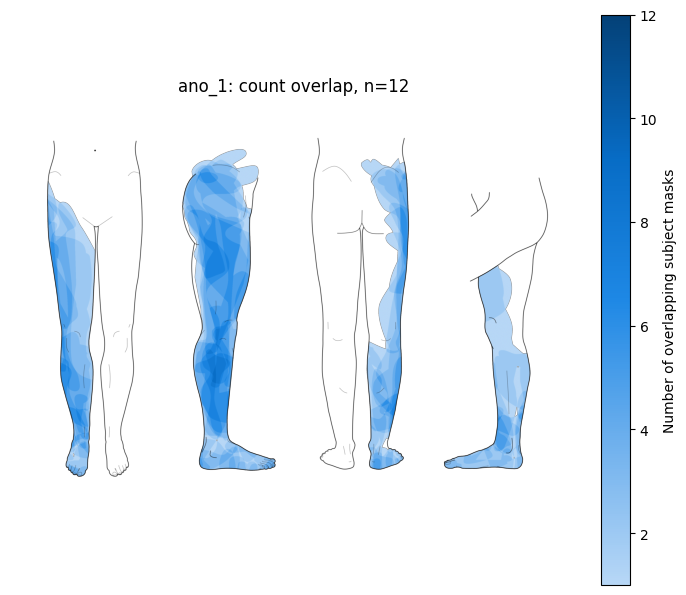

WindowsPath('export lumbar vanc/overlap_outputs/ano_1_overlap_count_with_outline.png')

In [39]:
result_ano_1 = create_overlap_heatmap(
    ROOT / "ano_1",
    output_path=OUTPUT_DIR / "ano_1_overlap_count_with_outline.png",
    mode="count",
    cmap=palette_for_folder(ROOT / "ano_1"),
    background="transparent",
    outline_path=ANATOMY_OUTLINE,
    outline_color="black",
    outline_alpha=1.0,
)

result_ano_1["output_path"]

## Process All `ano_*` Folders

This creates one count overlap PNG for each annotation folder, with the sensory anatomy outline drawn on top.

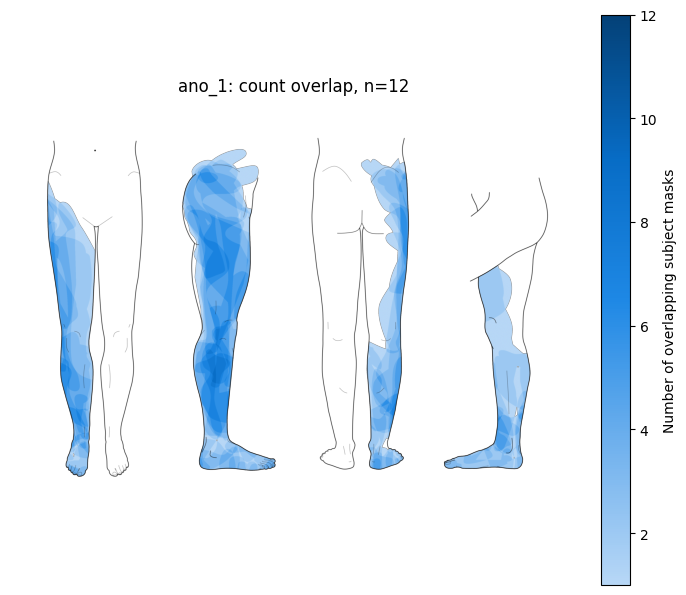

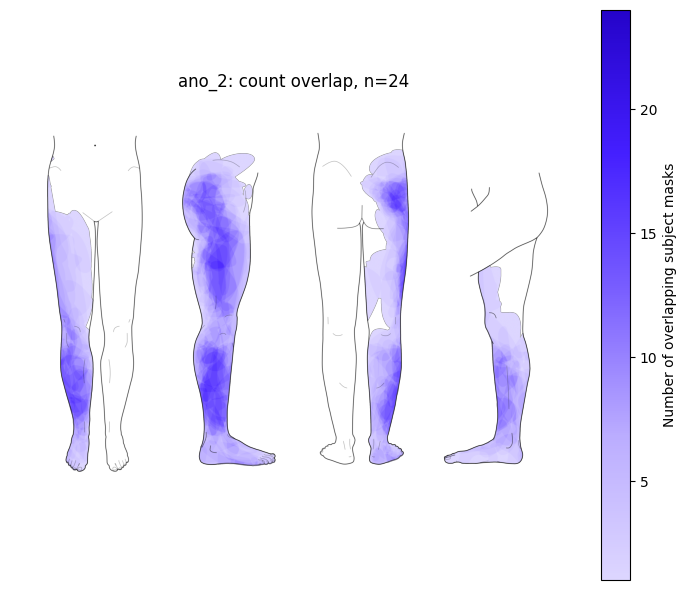

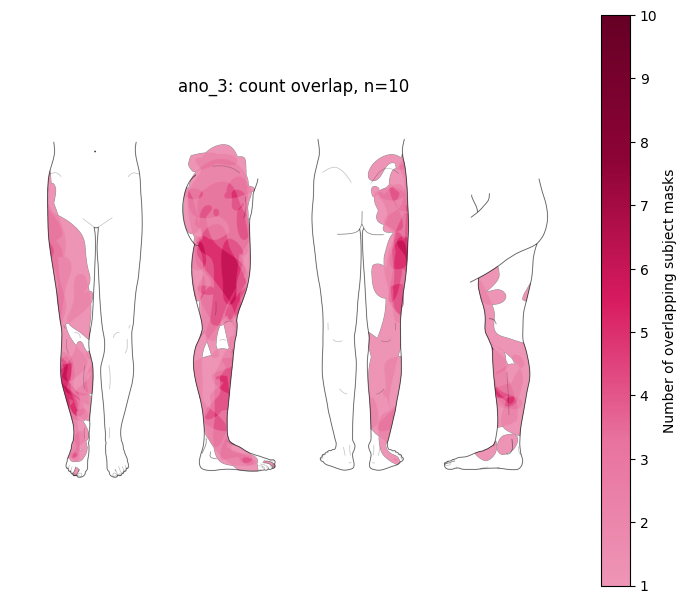

{'ano_1': 12, 'ano_2': 24, 'ano_3': 10}

In [40]:
count_results = {}

for folder in sorted(ROOT.glob("ano_*")):
    count_results[folder.name] = create_overlap_heatmap(
        folder,
        output_path=OUTPUT_DIR / f"{folder.name}_overlap_count_with_outline.png",
        mode="count",
        cmap=palette_for_folder(folder),
        background="transparent",
        outline_path=ANATOMY_OUTLINE,
        outline_color="black",
        outline_alpha=1.0,
        show=True,
    )

{name: result["n_subjects"] for name, result in count_results.items()}

## Percent Overlap Instead Of Count

Use `mode="percent"` when you want the color scale to represent percent of subjects instead of raw subject counts. `percent_color_range="auto"` stretches the palette over the observed positive percent range, while positive values outside an explicit range such as `(1, 80)` are drawn gray.

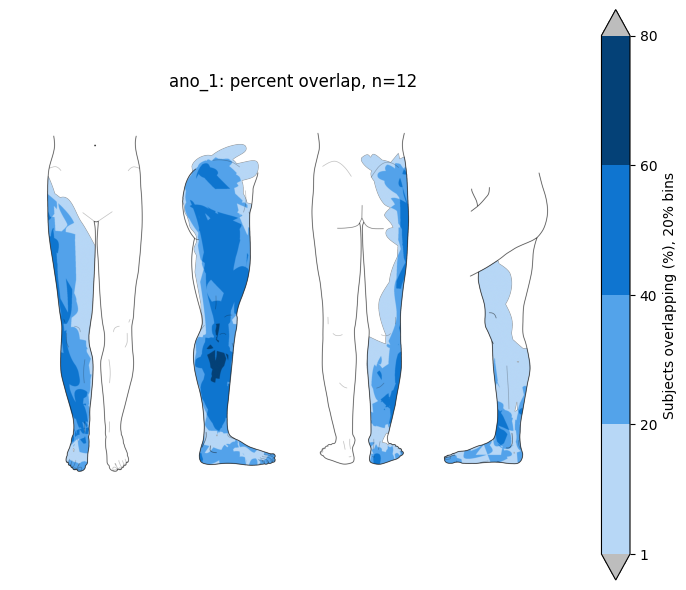

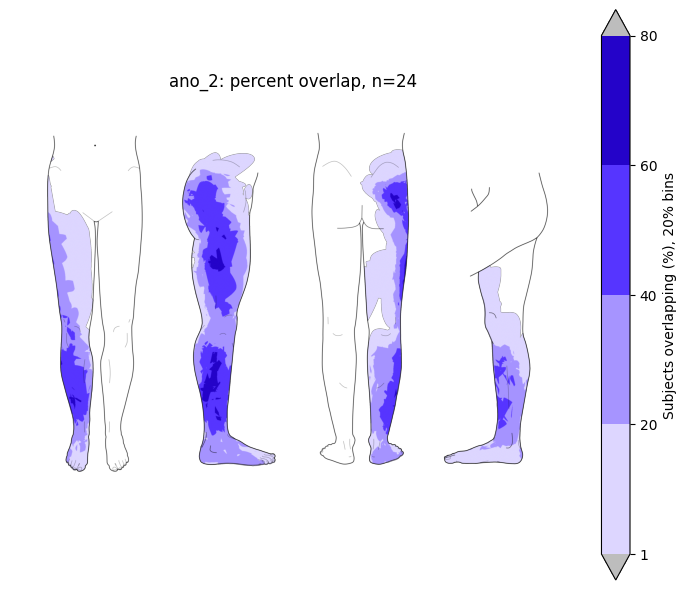

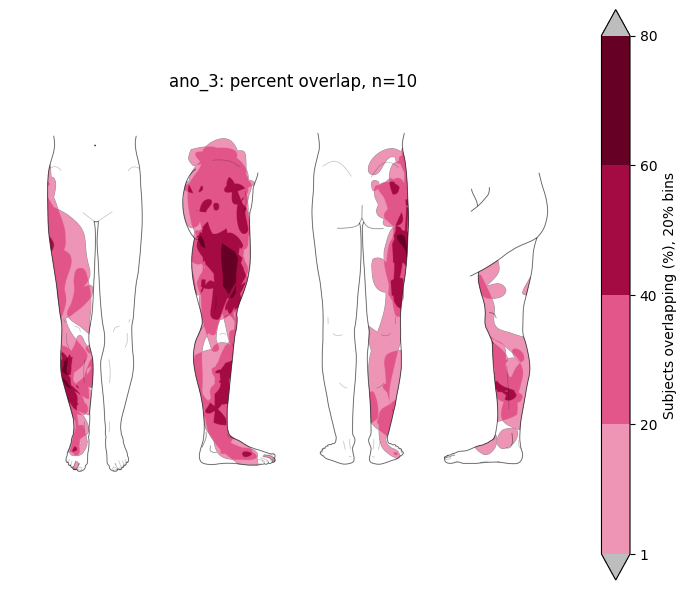

{'ano_1': WindowsPath('export lumbar vanc/overlap_outputs/ano_1_overlap_percent_with_outline.png'),
 'ano_2': WindowsPath('export lumbar vanc/overlap_outputs/ano_2_overlap_percent_with_outline.png'),
 'ano_3': WindowsPath('export lumbar vanc/overlap_outputs/ano_3_overlap_percent_with_outline.png')}

In [41]:
percent_results = {}

for folder in sorted(ROOT.glob("ano_*")):
    percent_results[folder.name] = create_overlap_heatmap(
        folder,
        output_path=OUTPUT_DIR / f"{folder.name}_overlap_percent_with_outline.png",
        mode="percent",
        cmap=palette_for_folder(folder),
        background="transparent",
        outline_path=ANATOMY_OUTLINE,
        outline_color="black",
        outline_alpha=1.0,
        percent_step=20,
        percent_color_range="auto",
        outside_range_color="#bdbdbd",
        show=True,
    )

{name: result["output_path"] for name, result in percent_results.items()}

## Subject-Specific Outlines

The heatmap still summarizes total overlap, but each individual subject mask can also be drawn as a boundary. By default, subject outlines are gray with linewidth 3 and alpha 0.95. You can still pass `subject_outline_cmap="auto"` or `subject_outline_colors=[...]` if you want subject-specific colors.

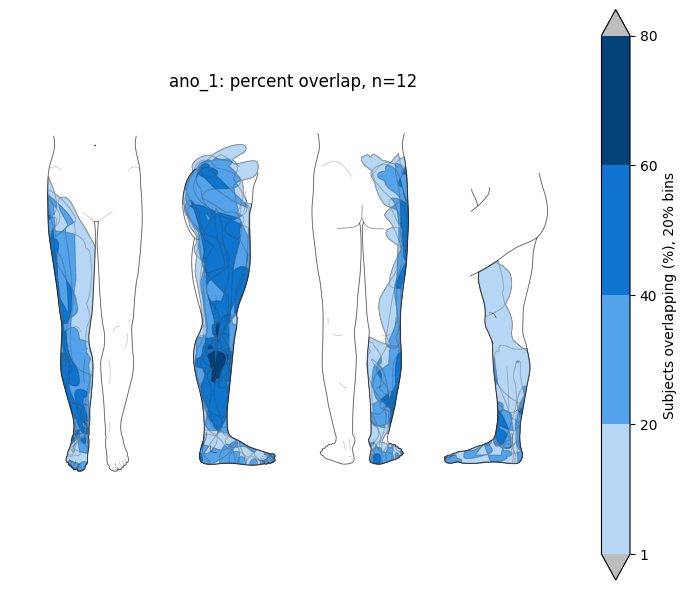

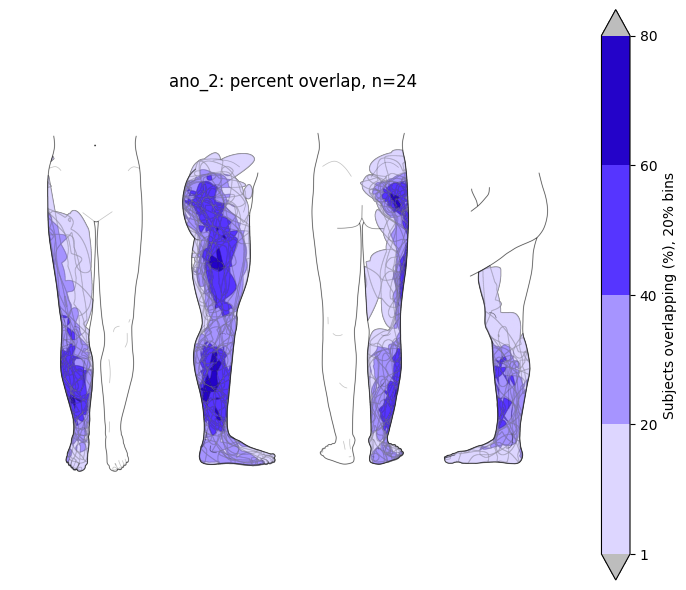

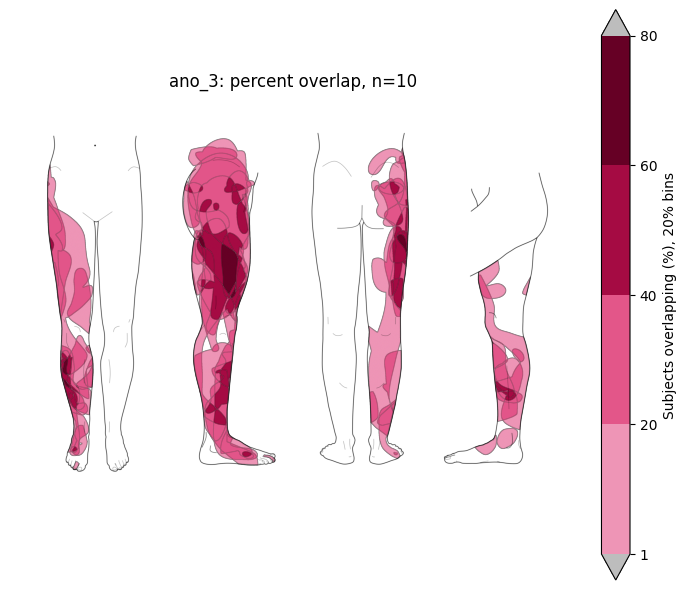

{'ano_1': {'case_1': '#737373',
  'case_10': '#737373',
  'case_11': '#737373',
  'case_12': '#737373',
  'case_2': '#737373',
  'case_3': '#737373',
  'case_4': '#737373',
  'case_5': '#737373',
  'case_6': '#737373',
  'case_7': '#737373',
  'case_8': '#737373',
  'case_9': '#737373'},
 'ano_2': {'case_1': '#737373',
  'case_10': '#737373',
  'case_11': '#737373',
  'case_12': '#737373',
  'case_13': '#737373',
  'case_14': '#737373',
  'case_15': '#737373',
  'case_16': '#737373',
  'case_17': '#737373',
  'case_18': '#737373',
  'case_19': '#737373',
  'case_2': '#737373',
  'case_20': '#737373',
  'case_21': '#737373',
  'case_22': '#737373',
  'case_23': '#737373',
  'case_24': '#737373',
  'case_3': '#737373',
  'case_4': '#737373',
  'case_5': '#737373',
  'case_6': '#737373',
  'case_7': '#737373',
  'case_8': '#737373',
  'case_9': '#737373'},
 'ano_3': {'case_1': '#737373',
  'case_10': '#737373',
  'case_2': '#737373',
  'case_3': '#737373',
  'case_4': '#737373',
  'case_5

In [43]:
subject_outline_results = {}

for folder in sorted(ROOT.glob("ano_*")):
    subject_outline_results[folder.name] = create_overlap_heatmap(
        folder,
        output_path=OUTPUT_DIR / f"{folder.name}_overlap_percent_with_subject_outlines.png",
        mode="percent",
        cmap=palette_for_folder(folder),
        background="transparent",
        outline_path=ANATOMY_OUTLINE,
        outline_color="black",
        outline_alpha=1,
        subject_outlines=True,
        subject_outline_alpha=0.50,
        subject_outline_width=3,
        show_subject_legend=False,
        percent_step=20,
        percent_color_range="auto",
        outside_range_color="#bdbdbd",
    )

{name: result["subject_outline_color_key"] for name, result in subject_outline_results.items()}

## Useful Adjustments

- Change `cmap` to any Matplotlib colormap, for example `"viridis"`, `"plasma"`, `"inferno"`, `"magma"`, `"turbo"`, or `"jet"`.
- Use `background="white"` if you want a regular opaque PNG instead of a transparent background.
- Set `outline_path=ANATOMY_OUTLINE` to draw `anatomy_only_sensory (1).png` on top of the heatmap.
- Change `outline_color`, `outline_alpha`, or `outline_threshold` if you want lighter, darker, or more/less inclusive anatomy lines.
- Set `subject_outlines=True` to draw one gray boundary per subject mask on top of the heatmap. Defaults are `subject_outline_width=3` and `subject_outline_alpha=0.95`.
- Change `subject_outline_width`, `subject_outline_alpha`, or pass `subject_outline_cmap="auto"` / `subject_outline_colors=[...]` if the subject boundaries are too subtle or you want subject-specific colors.
- Percent maps use `percent_step=10` by default, so each 10% interval gets one color. Use `percent_color_range="auto"` to stretch those bins over the observed positive range, or set `percent_color_range=(1, 80)` to gray out positive values outside 1-80%. Use `percent_step=None` for a continuous percent gradient.
- Use `threshold=200` or `threshold=50` if the PNGs are anti-aliased or not strictly black/white.
- Use `mask_color="white"` if a future mask set stores the selected regions as white instead of black.